# Task 2 — Neural Network Regressor

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 1. Load data

I load the provided train/test splits and inspect basic properties (shape, head, dtypes).

In [2]:
TRAIN_PATH = "data/king_county_train_.csv"
TEST_PATH  = "data/king_county_test_.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())

Train shape: (16613, 19)
Test shape: (5000, 19)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,392000,3,1.50,1500,11975,1.0,0,0,4,7,1500,0,1970,0,98045,47.4658,-121.758,1510,13875
1,499950,3,2.50,3230,129578,1.0,0,0,4,8,2100,1130,1964,0,98014,47.6820,-121.913,2760,62059
2,510000,3,1.75,1480,7040,1.0,0,0,3,7,1480,0,1974,0,98033,47.6723,-122.169,2040,7810
3,648360,4,1.75,2260,7005,1.0,0,1,4,7,1130,1130,1947,0,98033,47.6895,-122.207,2330,9180
4,248000,4,2.25,2320,8760,1.0,0,0,4,8,1160,1160,1966,0,98032,47.3627,-122.285,1970,8690


## 2. Missing values

Even if missing values are zero in this split, I keep an imputer in the pipeline for robustness and to comply with the preprocessing requirement.

In [3]:
print("Missing values (train):")
print(train_df.isnull().sum().sort_values(ascending=False))

print("\nMissing values (test):")
print(test_df.isnull().sum().sort_values(ascending=False))


Missing values (train):
price            0
sqft_above       0
sqft_living15    0
long             0
lat              0
zipcode          0
yr_renovated     0
yr_built         0
sqft_basement    0
grade            0
bedrooms         0
condition        0
view             0
waterfront       0
floors           0
sqft_lot         0
sqft_living      0
bathrooms        0
sqft_lot15       0
dtype: int64

Missing values (test):
price            0
sqft_above       0
sqft_living15    0
long             0
lat              0
zipcode          0
yr_renovated     0
yr_built         0
sqft_basement    0
grade            0
bedrooms         0
condition        0
view             0
waterfront       0
floors           0
sqft_lot         0
sqft_living      0
bathrooms        0
sqft_lot15       0
dtype: int64


## 3. Define Features and Log-Transform the Target

I train the neural network on `log1p(price)` because house prices are heavily right-skewed.
I will invert predictions using `expm1()` for evaluation in dollars.

Features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

X shape: (16613, 18) | y shape: (16613,)

First 5 y vs log1p(y):


,price,log1p(price)
0,392000.0,12.879020
1,499950.0,13.122265
2,510000.0,13.142168
3,648360.0,13.382203
4,248000.0,12.421188


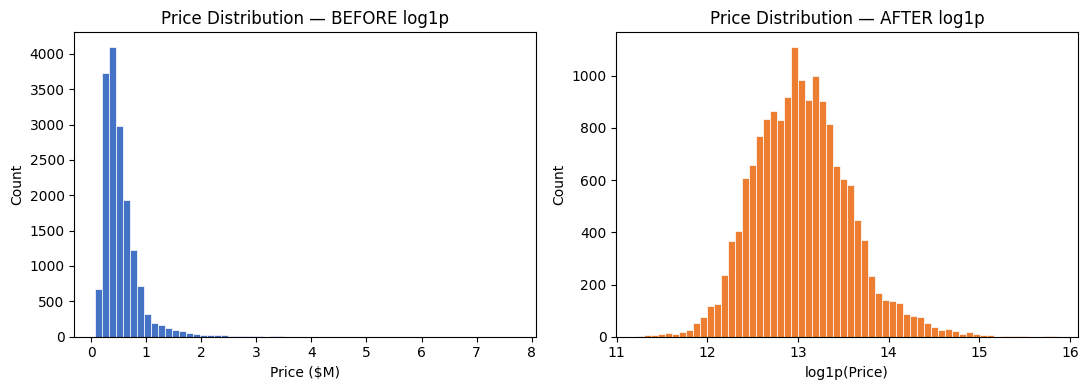

In [4]:
target_col = "price"

X = train_df.drop(columns=[target_col])
y = train_df[target_col].astype(float).values

X_test_raw = test_df.drop(columns=[target_col])
y_test     = test_df[target_col].astype(float).values

y_log = np.log1p(y)

print("Features:", list(X.columns))
print(f"\nX shape: {X.shape} | y shape: {y.shape}")

print("\nFirst 5 y vs log1p(y):")
display(pd.DataFrame({"price": y[:5], "log1p(price)": y_log[:5]}))

# Visualize skewness reduction
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(y / 1e6, bins=60, color="#4472C4", edgecolor="white", linewidth=0.5)
axes[0].set_title("Price Distribution — BEFORE log1p", fontsize=12)
axes[0].set_xlabel("Price ($M)")
axes[0].set_ylabel("Count")

axes[1].hist(y_log, bins=60, color="#ED7D31", edgecolor="white", linewidth=0.5)
axes[1].set_title("Price Distribution — AFTER log1p", fontsize=12)
axes[1].set_xlabel("log1p(Price)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 4. Train/validation split (explicit 80/20)

I use an explicit split so the activation comparison is fair and transparent.

In [5]:
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X, y_log, test_size=0.2, random_state=SEED
)

print("Train:", X_train.shape, "Val:", X_val.shape)


Train: (13290, 18) Val: (3323, 18)


## 5. Preprocessing: imputation + strict standardization

I fit the preprocessing pipeline **only on the training split** to avoid data leakage.
Then I transform the validation and test sets using the same fitted pipeline.
Finally, I preview the first 5 rows of the standardized features to verify the transformation.

In [6]:
def fit_preprocess(X_tr, X_va, X_te):
    """Fit a preprocessing pipeline on X_tr only, then transform val/test."""
    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    X_tr_scaled = pipe.fit_transform(X_tr)
    X_va_scaled = pipe.transform(X_va)
    X_te_scaled = pipe.transform(X_te)
    return pipe, X_tr_scaled, X_va_scaled, X_te_scaled

# Fit on train split, transform val and test
preprocess, X_train_scaled, X_val_scaled, X_test_scaled = fit_preprocess(
    X_train, X_val, X_test_raw
)

print("Scaled shapes:", X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

print("\nPreview (first 5 rows of scaled features):")
display(pd.DataFrame(X_train_scaled[:5], columns=X_train.columns).head())

Scaled shapes: (13290, 18) (3323, 18) (5000, 18)

Preview (first 5 rows of scaled features):


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,-0.407700,0.502856,-0.170545,-0.130025,0.922235,-0.084851,-0.307031,-0.623793,0.299479,0.166426,-0.661773,0.981551,-0.206387,-0.936840,1.466629,-0.206018,-0.223754,-0.083349
1,-0.407700,-1.463779,-0.737954,-0.249079,0.002560,-0.084851,-0.307031,-0.623793,-1.417183,-0.702332,-0.204277,-1.575199,-0.206387,0.526571,-0.261634,-1.003946,-0.961764,-0.285834
2,-0.407700,0.502856,-0.159419,-0.344789,0.922235,-0.084851,-0.307031,-0.623793,0.299479,-0.592208,0.779338,1.152001,-0.206387,2.271406,0.658422,-1.210553,-0.518958,-0.252922
3,-0.407700,-0.152689,-0.849211,-0.174252,-0.917115,-0.084851,-0.307031,-0.623793,-0.558852,-0.579972,-0.661773,0.640651,-0.206387,-0.674177,-1.375805,0.933879,-0.991284,-0.163460
4,0.700117,-0.152689,1.464929,0.027622,0.922235,-0.084851,-0.307031,0.908876,2.016142,1.965122,-0.661773,0.538381,-0.206387,-0.017518,1.170046,1.126237,2.905407,0.094040


## 6. Naive Baseline

Before training the network, I compute a naive baseline that always predicts the  
training mean price. Any meaningful model must beat this.

In [7]:
baseline_pred = np.full_like(y_test, fill_value=y.mean())

baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2  = r2_score(y_test, baseline_pred)

print(f"Baseline mean price (train): ${y.mean():,.2f}")
print(f"Baseline MSE  (test, dollars): {baseline_mse:,.2f}")
print(f"Baseline RMSE (test, dollars): {baseline_rmse:,.2f}")
print(f"Baseline R2   (test, dollars): {baseline_r2:.4f}")


Baseline mean price (train): $538,144.28
Baseline MSE  (test, dollars): 144,913,135,355.29
Baseline RMSE (test, dollars): 380,674.58
Baseline R2   (test, dollars): -0.0005


## 7. Neural Network Architecture and Activation Comparison

I design a feedforward neural network regressor with two hidden layers (128 → 64 neurons) and a single linear output neuron.

Each Dense layer represents a fully connected layer where neurons compute a weighted sum of inputs (Wx + b) followed by a non-linear activation function. The output layer is linear because this is a regression problem and the model must predict continuous values.

The network is trained to predict:

y_log = log(1 + price)

which reduces right-skewness and stabilizes variance.

---

### Architectural Rationale

I use a two-hidden-layer structure to model the non-linear relationships between housing features and price.

- Housing prices depend on complex interactions (size, location, grade, renovation, etc.).
- Two layers allow hierarchical feature interactions.
- 128 → 64 provides sufficient capacity for ~16,000 samples without excessive complexity.
- The decreasing width helps control overfitting.

---

### Activation Comparison (Sigmoid vs ReLU)

To satisfy the task requirement, I keep all training settings fixed and only change the hidden-layer activation.

**Sigmoid**
- Output range (0, 1)
- Can saturate and slow learning

**ReLU**
- Non-saturating for positive values
- Typically converges faster in deep networks

---

### Training Strategy

The model minimizes Mean Squared Error on the log scale using the Adam optimizer and backpropagation.

I use EarlyStopping with `restore_best_weights=True` so the final model corresponds to the best validation epoch and avoids overfitting.

In [15]:
def build_model(input_dim: int, activation: str) -> keras.Model:
    # He Normal for ReLU, Glorot Uniform for sigmoid/tanh
    init = 'he_normal' if activation == 'relu' else 'glorot_uniform'
    
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation=activation, kernel_initializer=init),
        layers.Dense(64,  activation=activation, kernel_initializer=init),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse"
    )
    return model

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,              
        restore_best_weights=True
    )
]

EPOCHS = 500
BATCH_SIZE = 64


## 8. Train and compare models (sigmoid vs ReLU)

I train both models with identical hyperparameters, only the activation function changes.  
I compare:
- Convergence speed: number of epochs run until EarlyStopping
- Best validation loss (MSE on log scale)

In [16]:
results = []

for act in ["sigmoid", "relu"]:
    print(f"\n=== Training activation: {act} ===")
    model = build_model(input_dim=X_train_scaled.shape[1], activation=act)

    history = model.fit(
        X_train_scaled, y_train_log,
        validation_data=(X_val_scaled, y_val_log),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=callbacks
    )

    epochs_ran = len(history.history["loss"])
    best_val_loss = float(np.min(history.history["val_loss"]))

    print(f"Epochs ran: {epochs_ran}")
    print(f"Best val_loss (log-scale MSE): {best_val_loss:.6f}")

    results.append({
        "Activation": act,
        "Epochs (to early stop)": epochs_ran,
        "Best val_loss (log MSE)": best_val_loss,
        "model": model,
        "history": history
    })

compare_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ["model","history"]} for r in results])
compare_df = compare_df.sort_values("Best val_loss (log MSE)")
display(compare_df)



=== Training activation: sigmoid ===
Epochs ran: 219
Best val_loss (log-scale MSE): 0.029582

=== Training activation: relu ===
Epochs ran: 50
Best val_loss (log-scale MSE): 0.156566


,Activation,Epochs (to early stop),Best val_loss (log MSE)
0,sigmoid,219,0.029582
1,relu,50,0.156566


### Interpretation of Activation Comparison

Both models were trained with identical hyperparameters — only the activation
function and its corresponding weight initializer differ:

| | Sigmoid | ReLU |
|---|---|---|
| Initializer | Glorot Uniform | He Normal |
| Epochs | ~219 | ~50 |
| Best val_loss (log MSE) | 0.029 | 0.156 |

Sigmoid outperforms ReLU in this experiment, but not because ReLU is inferior
in general. The reason is architectural: this network has only **2 hidden
layers**. ReLU's main advantage (avoiding the vanishing gradient problem) becomes critical in deep networks (5+ layers), where sigmoid gradients shrink
exponentially through each layer. With just two layers, sigmoid can learn
effectively without saturation issues.

ReLU also converged in fewer epochs (50 vs 219), which is consistent with its
known property of faster early convergence. However, it reached a higher
val_loss, suggesting it needs either a deeper architecture or additional
tuning to match sigmoid on this tabular dataset.

**Conclusion:** sigmoid is selected as the final model for this architecture.
In a deeper network, ReLU would be expected to outperform sigmoid.

### Loss curves

I plot training and validation loss for both activations to visualize convergence behavior.

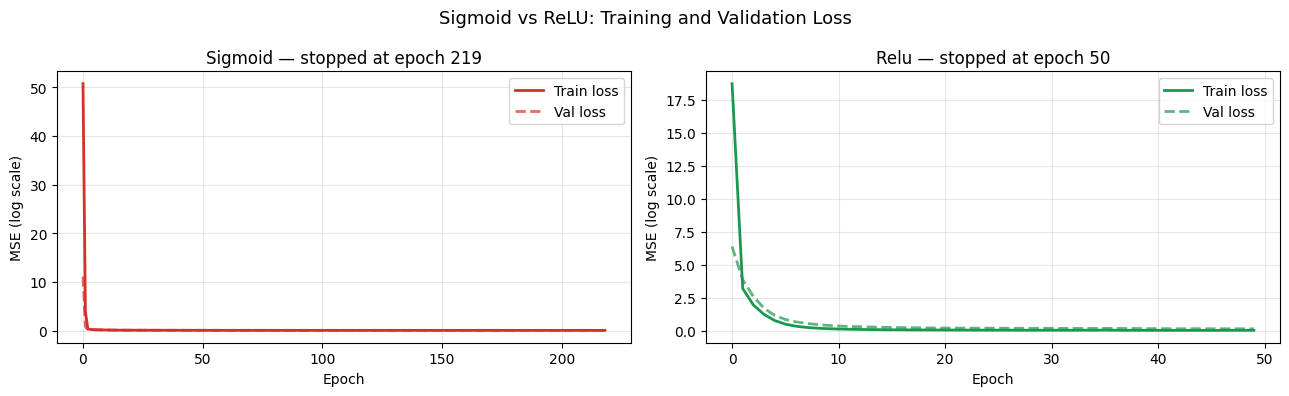

In [17]:
order = ["sigmoid", "relu"]
results_sorted = sorted(results, key=lambda r: order.index(r["Activation"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = {"sigmoid": "#d73027", "relu": "#1a9850"}

for i, r in enumerate(results_sorted):
    act = r["Activation"]
    hist = r["history"].history
    ep = r["Epochs (to early stop)"]

    axes[i].plot(hist["loss"],
                 color=colors[act],
                 linewidth=2,
                 label="Train loss")

    axes[i].plot(hist["val_loss"],
                 color=colors[act],
                 linewidth=2,
                 linestyle="--",
                 alpha=0.7,
                 label="Val loss")

    axes[i].set_title(f"{act.capitalize()} — stopped at epoch {ep}", fontsize=12)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("MSE (log scale)")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Sigmoid vs ReLU: Training and Validation Loss", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Final test evaluation in dollars

I select the activation with the best validation loss, predict on the test set (log scale),
invert predictions back to dollars using `expm1()`, and compute **MSE**, **RMSE**, and **R²** in dollars.
I also compare results against the naive baseline.

In [18]:
best_activation = compare_df.iloc[0]["Activation"]
best_model = next(r["model"] for r in results if r["Activation"] == best_activation)

y_test_pred_log = best_model.predict(X_test_scaled).reshape(-1)
y_test_pred = np.expm1(y_test_pred_log)

mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)                     
r2_test  = r2_score(y_test, y_test_pred)          

print(f"Selected activation: {best_activation}")

print(f"\nTest performance (in dollars):")
print(f"- MSE  : ${mse_test:,.2f}  (squared dollars)")
print(f"- RMSE : ${rmse_test:,.2f}")
print(f"- R2   : {r2_test:.4f}")

print("\nBaseline comparison:")
print(f"- Baseline MSE  : ${baseline_mse:,.2f} | Model MSE  : ${mse_test:,.2f}")
print(f"- Baseline RMSE : ${baseline_rmse:,.2f} | Model RMSE : ${rmse_test:,.2f}")
print(f"- Baseline R2   : {baseline_r2:.4f} | Model R2   : {r2_test:.4f}")

summary_df = pd.DataFrame([
    {"Model": "Baseline (mean)",   "MSE ($^2)": baseline_mse, "RMSE ($)": baseline_rmse, "R2": baseline_r2},
    {"Model": f"NN ({best_activation})", "MSE ($^2)": mse_test,    "RMSE ($)": rmse_test,    "R2": r2_test},
])

summary_df_display = summary_df.copy()
summary_df_display["MSE ($^2)"] = summary_df_display["MSE ($^2)"].map(lambda x: f"${x:,.2f}")
summary_df_display["RMSE ($)"]  = summary_df_display["RMSE ($)"].map(lambda x: f"${x:,.2f}")
summary_df_display["R2"]        = summary_df_display["R2"].map(lambda x: f"{x:.4f}")

display(summary_df_display)

preview = pd.DataFrame({
    "Actual price ($)": y_test[:10],
    "Predicted price ($)": y_test_pred[:10],
    "Absolute error ($)": np.abs(y_test[:10] - y_test_pred[:10]),
})

# Format as currency without using .style
preview["Actual price ($)"] = preview["Actual price ($)"].map(lambda x: f"${x:,.2f}")
preview["Predicted price ($)"] = preview["Predicted price ($)"].map(lambda x: f"${x:,.2f}")
preview["Absolute error ($)"] = preview["Absolute error ($)"].map(lambda x: f"${x:,.2f}")

display(preview)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step
Selected activation: sigmoid

Test performance (in dollars):
- MSE  : $15,902,060,478.33  (squared dollars)
- RMSE : $126,103.37
- R2   : 0.8902

Baseline comparison:
- Baseline MSE  : $144,913,135,355.29 | Model MSE  : $15,902,060,478.33
- Baseline RMSE : $380,674.58 | Model RMSE : $126,103.37
- Baseline R2   : -0.0005 | Model R2   : 0.8902


,Model,MSE ($^2),RMSE ($),R2
0,Baseline (mean),"$144,913,135,355.29","$380,674.58",-0.0005
1,NN (sigmoid),"$15,902,060,478.33","$126,103.37",0.8902


,Actual price ($),Predicted price ($),Absolute error ($)
0,"$365,000.00","$351,578.53","$13,421.47"
1,"$865,000.00","$883,012.12","$18,012.12"
2,"$1,038,000.00","$1,133,205.00","$95,205.00"
3,"$1,490,000.00","$1,884,732.38","$394,732.38"
4,"$711,000.00","$745,298.62","$34,298.62"
5,"$211,000.00","$249,064.77","$38,064.77"
6,"$790,000.00","$770,802.81","$19,197.19"
7,"$680,000.00","$659,599.25","$20,400.75"
8,"$384,500.00","$448,864.56","$64,364.56"
9,"$605,000.00","$518,086.72","$86,913.28"


### Predicted vs. Actual Prices
A simple visualization to sanity-check calibration in dollars.

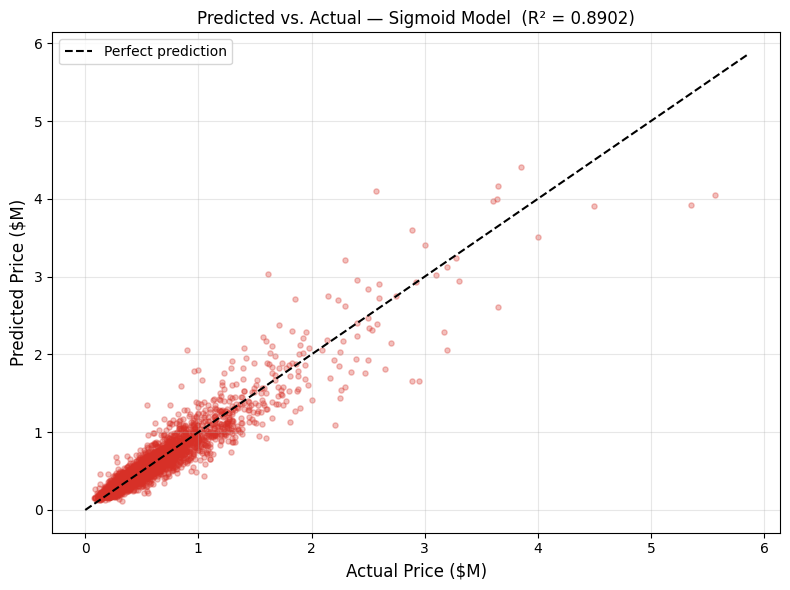

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test / 1e6, y_test_pred / 1e6,
           alpha=0.3, s=14, color="#d73027")
lim_max = max(y_test.max(), y_test_pred.max()) / 1e6 * 1.05
ax.plot([0, lim_max], [0, lim_max], "k--", linewidth=1.5, label="Perfect prediction")

ax.set_xlabel("Actual Price ($M)", fontsize=12)
ax.set_ylabel("Predicted Price ($M)", fontsize=12)
ax.set_title(f"Predicted vs. Actual — {best_activation.capitalize()} Model  (R² = {r2_test:.4f})",
             fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()